In [1]:
# -----------------------------
# IMPORT LIBRARIES
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [2]:
# -----------------------------
# LOAD FEATURE ENGINEERED DATA
# -----------------------------

sales = pd.read_csv(
    "../data/processed/feature_engineered_sales.csv"
)

In [3]:
# Convert date column
sales["date"] = pd.to_datetime(
    sales["date"]
)

In [4]:
# -----------------------------
# CREATE PREDICTED DEMAND
# -----------------------------
# Using sales as forecasted demand proxy

sales["predicted_demand"] = sales["sales"]

In [5]:
# -----------------------------
# SIMULATE CURRENT INVENTORY
# -----------------------------
# More realistic stock levels

sales["current_stock"] = np.random.randint(
    5000,
    15000,
    size=len(sales)
)

In [6]:
# -----------------------------
# SIMULATE LEAD TIME (WEEKS)
# -----------------------------
# IMPORTANT:
# Since demand is weekly,
# lead time should also be weekly

sales["lead_time_weeks"] = np.random.randint(
    1,
    4,
    size=len(sales)
)

In [7]:
# -----------------------------
# CALCULATE DEMAND VARIABILITY
# -----------------------------

demand_std = sales["predicted_demand"].std()

In [8]:
# -----------------------------
# SERVICE LEVEL
# -----------------------------
# 95% service level

z_score = 1.65

In [9]:
# -----------------------------
# SAFETY STOCK
# -----------------------------
# Formula:
# SS = Z × σ × √LT

sales["safety_stock"] = (
    z_score
    * demand_std
    * np.sqrt(sales["lead_time_weeks"])
)

In [10]:
# -----------------------------
# REORDER POINT
# -----------------------------
# Formula:
# ROP = (Demand × Lead Time) + Safety Stock

sales["reorder_point"] = (

    sales["predicted_demand"]
    * sales["lead_time_weeks"]

) + sales["safety_stock"]

In [11]:
# -----------------------------
# REORDER ALERTS
# -----------------------------

sales["reorder_alert"] = np.where(

    sales["current_stock"]
    <= sales["reorder_point"],

    "Reorder Needed",

    "Stock Sufficient"
)

In [12]:
# -----------------------------
# RECOMMENDED ORDER QUANTITY
# -----------------------------

sales["recommended_order_qty"] = np.where(

    sales["current_stock"]
    <= sales["reorder_point"],

    sales["reorder_point"]
    - sales["current_stock"],

    0
)

In [13]:
sales["inventory_status"] = np.where(

    sales["current_stock"]
    < sales["safety_stock"],

    "Critical Stock",

    np.where(

        sales["current_stock"]
        < sales["reorder_point"],

        "Low Stock",

        "Healthy Stock"
    )
)

In [14]:
# -----------------------------
# VIEW FINAL OUTPUT
# -----------------------------

final_inventory = sales[[

    "date",
    "predicted_demand",
    "current_stock",
    "lead_time_weeks",
    "safety_stock",
    "reorder_point",
    "recommended_order_qty",
    "reorder_alert",
    "inventory_status"

]]

In [15]:
final_inventory.head()


,date,predicted_demand,current_stock,lead_time_weeks,safety_stock,reorder_point,recommended_order_qty,reorder_alert,inventory_status
0,2016-11-13,0,14825,2,1605.148606,1605.148606,0.0,Stock Sufficient,Healthy Stock
1,2016-11-20,0,9419,3,1965.897523,1965.897523,0.0,Stock Sufficient,Healthy Stock
2,2016-11-27,0,11069,1,1135.011464,1135.011464,0.0,Stock Sufficient,Healthy Stock
3,2016-12-04,0,8251,2,1605.148606,1605.148606,0.0,Stock Sufficient,Healthy Stock
4,2016-12-11,0,6891,1,1135.011464,1135.011464,0.0,Stock Sufficient,Healthy Stock


In [16]:
# -----------------------------
# SAVE FINAL INVENTORY DATASET
# -----------------------------

final_inventory.to_csv(

    "../data/processed/inventory_optimization.csv",

    index=False
)

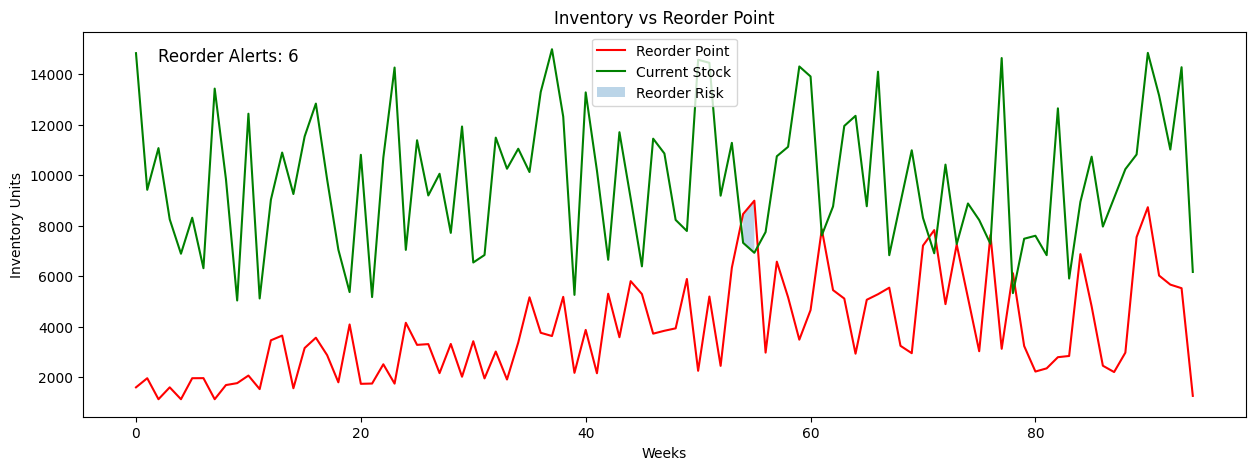

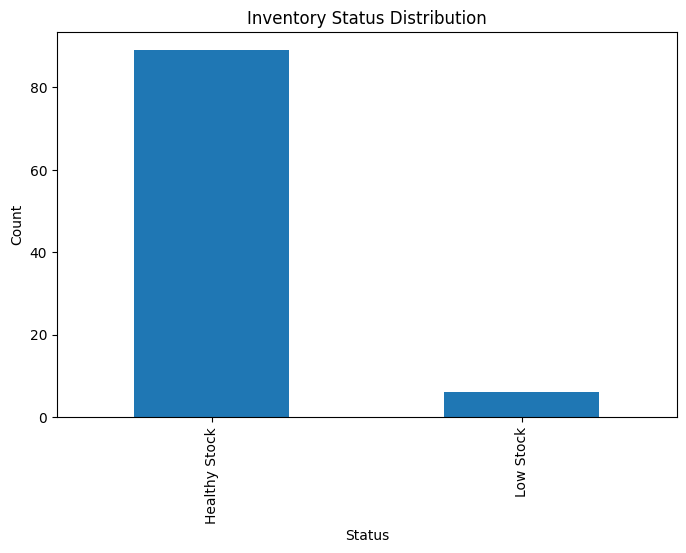

In [17]:
# =========================================================
# VISUALIZATIONS
# =========================================================

# -----------------------------
# INVENTORY VS REORDER POINT
# -----------------------------

# -----------------------------
# INVENTORY VS REORDER POINT
# WITH RISK HIGHLIGHT
# -----------------------------


plt.figure(figsize=(15,5))

# Reorder point line
plt.plot(

    sales["reorder_point"].values,

    label="Reorder Point",
    color="red"
)

# Current stock line
plt.plot(

    sales["current_stock"].values,

    label="Current Stock",
    color="green"
)

# Highlight reorder risk zones
plt.fill_between(

    range(len(sales)),

    sales["current_stock"],

    sales["reorder_point"],

    where=(
        sales["current_stock"]
        < sales["reorder_point"]
    ),

    alpha=0.3,

    label="Reorder Risk"
)

# -----------------------------
# KPI TEXT
# -----------------------------

plt.text(

    2,              # X Position
    14500,          # Y Position

    f"Reorder Alerts: {(sales['reorder_alert'] == 'Reorder Needed').sum()}",

    fontsize=12
)


plt.legend()

plt.title(
    "Inventory vs Reorder Point"
)

plt.xlabel("Weeks")

plt.ylabel("Inventory Units")

plt.show()

# -----------------------------
# INVENTORY STATUS COUNT
# -----------------------------

inventory_counts = sales[
    "inventory_status"
].value_counts()

inventory_counts.plot(
    kind="bar",
    figsize=(8,5)
)
plt.title(
    "Inventory Status Distribution"
)

plt.xlabel("Status")

plt.ylabel("Count")

plt.show()



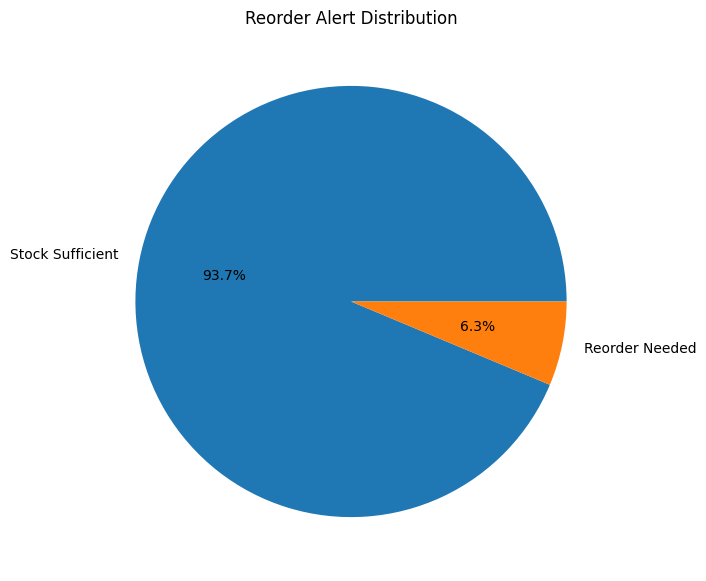

In [18]:
# -----------------------------
# REORDER ALERT DISTRIBUTION
# -----------------------------

alert_counts = sales[
    "reorder_alert"
].value_counts()

alert_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title(
    "Reorder Alert Distribution"
)

plt.ylabel("")

plt.show()

In [19]:
# =========================================================
# SUMMARY STATISTICS
# =========================================================

print("\n===== INVENTORY SUMMARY =====")

print(
    "Average Predicted Demand:",
    round(
        sales["predicted_demand"].mean(),
        2
    )
)

print(
    "Average Current Stock:",
    round(
        sales["current_stock"].mean(),
        2
    )
)

print(
    "Average Reorder Point:",
    round(
        sales["reorder_point"].mean(),
        2
    )
)

print(
    "Products Requiring Reorder:",
    (
        sales["reorder_alert"]
        == "Reorder Needed"
    ).sum()
)

print(
    "Critical Stock Products:",
    (
        sales["inventory_status"]
        == "Critical Stock"
    ).sum()
)





===== INVENTORY SUMMARY =====
Average Predicted Demand: 1156.64
Average Current Stock: 9783.72
Average Reorder Point: 3860.66
Products Requiring Reorder: 6
Critical Stock Products: 0
